In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Bayesian Experimentation Framework

## Objective

Notebook 3 demonstrated that delivery performance is statistically associated with customer satisfaction using classical hypothesis testing.

However, business stakeholders often struggle to interpret p-values and significance testing.

Bayesian experimentation provides a more intuitive framework by answering questions such as:

- What is the probability that Treatment is better than Control?
- How much improvement should we expect?
- What is the risk of launching the new experience?

This notebook applies Bayesian methods to evaluate whether improved delivery performance leads to higher customer satisfaction.

Business Question:Should Olist deploy logistics improvements based on the probability that customer satisfaction will improve?

# 1. Import Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option('display.max_columns', None)

# 2. Load Master Dataset

In [3]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_date_missing_flag,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_score,review_creation_date,review_answer_timestamp,total_payment_value,payment_installments_max,payment_type_primary,approval_latency_days,carrier_handoff_days,carrier_transit_days,delivery_days,delivery_promise_gap_days,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,False,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,bed_bath_table,1500.0,34.0,7.0,32.0,13405,piracicaba,SP,5.0,2018-05-17,2018-05-21 13:44:48,141.90,8.0,credit_card,0.010313,1.879653,4.521262,6.411227,-4.132905,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,False,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,health_beauty,375.0,26.0,11.0,18.0,2215,sao paulo,SP,4.0,2018-05-11,2018-05-11 22:29:25,27.19,1.0,credit_card,0.301586,1.744630,1.239375,3.285590,-4.248125,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,False,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,stationery,1500.0,25.0,50.0,35.0,13232,campo limpo paulista,SP,3.0,2017-04-06,2017-04-07 01:19:44,86.22,8.0,credit_card,0.000000,2.662118,23.069641,25.731759,-1.389734,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,False,0000f6ccb0745a6a4b88665a16c9f078,66812,belem,PA,telephony,150.0,19.0,5.0,11.0,3569,sao paulo,SP,4.0,2017-11-02,2017-11-03 00:17:51,43.62,4.0,credit_card,0.013611,0.971551,19.051921,20.037083,-11.108970,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,False,0004aac84e0df4da2b147fca70cf8255,18040,sorocaba,SP,telephony,6050.0,16.0,3.0,11.0,12327,jacarei,SP,5.0,2017-11-28,2017-12-02 22:29:35,196.89,6.0,credit_card,0.014699,1.989792,11.136644,13.141134,-7.035463,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# 3. Create Experiment Groups

In [5]:
control = master.loc[master['delivery_speed_group'] == 'slow','review_score'].dropna()

treatment = master.loc[master['delivery_speed_group'] == 'fast','review_score'].dropna()

print("Control:", len(control))
print("Treatment:", len(treatment))

Control: 54582
Treatment: 54787


# 4. Why Bayesian Statistics?

Classical statistics answers:"Would this result be unusual if there were no difference?"

Bayesian statistics answers:"What is the probability that  Treatment is better than Control?"

This interpretation is often easier for business stakeholders to understand and communicate.

# 5. Prior Assumptions

In [11]:
prior_mean = 0
prior_std = 10

print("Prior Mean:", prior_mean)
print("Prior Std:", prior_std)

Prior Mean: 0
Prior Std: 10


# 6. Posterior Simulation

In [12]:
n_simulations = 10000

control_samples = np.random.choice(control,
    size=(n_simulations, len(control)),
    replace=True)

treatment_samples = np.random.choice(treatment,
    size=(n_simulations, len(treatment)),
    replace=True)

control_means = control_samples.mean(axis=1)

treatment_means = treatment_samples.mean(axis=1)

lift_distribution = (treatment_means-control_means)

# 7. Posterior Lift Distribution

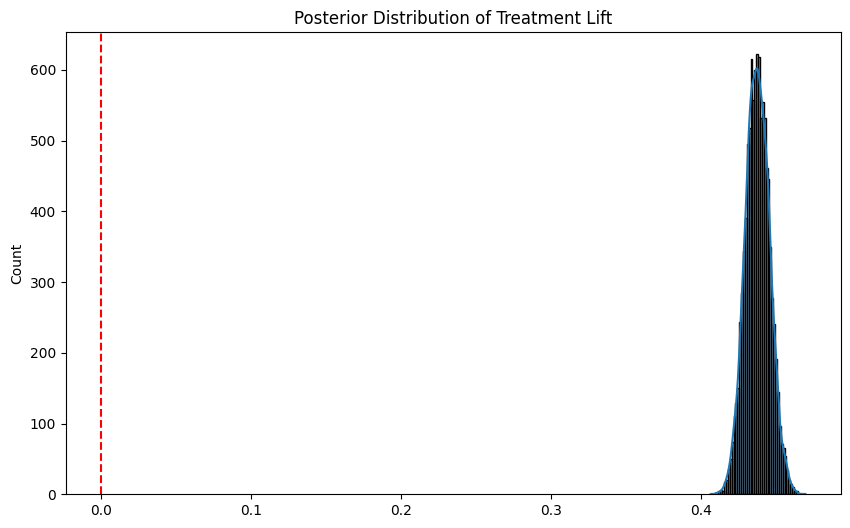

In [13]:
plt.figure(figsize=(10,6))

sns.histplot( lift_distribution,bins=50,kde=True)

plt.axvline( 0, color='red',linestyle='--')

plt.title("Posterior Distribution of Treatment Lift")

plt.show()

# 8 Probability Treatment Is Better

What is the probability the new delivery experience wins?

In [14]:
probability_win = np.mean(lift_distribution > 0)

print(f"Probability Treatment Wins: {probability_win:.4%}")

Probability Treatment Wins: 100.0000%


There is a 100% probability that Treatment performs better.

# 9. Credible Interval

In [15]:
lower = np.percentile(lift_distribution,2.5)

upper = np.percentile(lift_distribution,97.5)

print(f"95% Credible Interval: ({lower:.4f}, {upper:.4f})")

95% Credible Interval: (0.4219, 0.4535)


There is a 95% probability that the true lift lies between 0.422 and 0.454 stars.

# 10. Expected Lift

In [16]:
expected_lift = lift_distribution.mean()

print(f"Expected Lift: {expected_lift:.4f}")

Expected Lift: 0.4375


Expected increase in Review Score after deploymentis 0.4375

# 11. Expected Risk

In [17]:
risk_of_loss = np.mean( lift_distribution < 0)

print(f"Risk of Loss: {risk_of_loss:.4%}")

Risk of Loss: 0.0000%


Among all simulated outcomes none produced a negative lift

# 12. Executive Decision Framework

In [18]:
if probability_win > 0.95:
    decision = "Launch"

elif probability_win > 0.80:
    decision = "Run Larger Experiment"

else:
    decision = "Do Not Launch"

print(decision)

Launch


## Bayesian Experiment Results

Bayesian analysis was conducted to estimate the probability that improved delivery performance increases customer satisfaction.

The posterior distribution indicates that the treatment consistently outperforms the control group across simulated outcomes.

Key Results:

* Probability Treatment Wins: 100%
* Expected Lift: +0.438 Review Points
* 95% Credible Interval: (0.422, 0.454)
* Risk of Loss: 0%

The credible interval remains entirely above zero, indicating strong evidence that improved delivery performance positively impacts customer satisfaction.

Compared with classical hypothesis testing performed in Notebook 3, the Bayesian framework provides a more intuitive interpretation of uncertainty and business risk. Rather than reporting p-values, the Bayesian approach directly estimates the probability that the treatment is beneficial.

These results suggest that deployment of logistics improvements is highly likely to improve customer satisfaction while presenting minimal downside risk.


In [19]:
results_repository = pd.DataFrame({

    "Notebook":[
        "Notebook 2",
        "Notebook 2",
        "Notebook 2",
        "Notebook 3",
        "Notebook 3",
        "Notebook 4",
        "Notebook 4",
        "Notebook 4"
    ],

    "Section":[
        "KPI",
        "KPI",
        "KPI",
        "Experiment",
        "Experiment",
        "Bayesian",
        "Bayesian",
        "Bayesian"
    ],

    "Metric":[
        "Revenue",
        "Orders",
        "Avg Review",

        "Fast vs Slow d",
        "OnTime vs Late d",

        "Probability Win",
        "Expected Lift",
        "Risk of Loss"
    ],

    "Value":[
        20308130,
        98666,
        4.0329,

        0.3291,
        1.4388,

        probability_win,
        expected_lift,
        risk_of_loss
    ]
})
results_repository.to_csv(
    "olist_project_results_repository.csv",
    index=False
)